### Preparing a dataset for supervised instruction fine-tuning

In [1]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r") as file:
        data = json.load(file)
    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)


data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [2]:
# Let's see how each entry is structured
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [3]:
# Let's take a look at another example
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


**Exercise 7.1: Changing prompt styles**

After fine-tuning the model with the Alpaca prompt style, try the Phi-3 prompt style and observe whether it affects the response quality of the model.

In [4]:
# Define a format function to convert each entry of data in the Alpaca-style
# input format
def format_input(entry):
  instruction_text = (
      f"Below is an instruction that describes a task. "
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['instruction']}"
  )

  input_text = (
      f"\n\n### Input:\n{entry['input']}" if entry['input'] else ''
  )

  return instruction_text + input_text

In [5]:
# Let's test the formatting function on the data entry we saw earlier
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [7]:
# Note that the format_input skips the optional ### Input: section if the
# 'input' field is empty
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [8]:
# Before creating dataloaders, let's split the dataset into training,
# validation and test sets.
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion: train_portion + test_portion]
val_data = data[train_portion + test_portion: ]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


### Organizing data into training batches

In [10]:
# The batching process for instruction fine-tuning is a little bit more
# involved and we will have to write our custom collate function to group
# data samples into batches inside the data loader. First, let's start by
# writing a Dataset class that formats the data sample using the
# format_input function and then tokenizes the resulting formatted text
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data
    self.encoded_text = []
    for entry in data:
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_text.append(tokenizer.encode(full_text))

  def __getitem__(self, index):
    return self.encoded_text[index]

  def __len__(self):
    return len(self.data)

In [11]:
# Similar with the approach we used during classification fine-tuning,
# to process input data efficiently during training we need to batch
# single examples together, and to do that we need to pad the sequences
# to a uniform length (of the longest example sequence in the batch).
# As a reminder let's look again the token ID of the <|endoftext|>
# token we use for padding
import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')
print(tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'}))

[50256]


In [12]:
# Passing this collate function to the dataloader will ensure that each sample
# in a single batch will have the same lenght by padding the shorter sequences
# to the longest one in the same batch. This minimizes unnecessary padding as
# single batches are allowed to be of different length
import torch

def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device='cpu',
):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst = []

  for item in batch:
    new_item = item.copy()
    new_item +=[pad_token_id]

    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    inputs_lst.append(inputs)

  inputs_tensor = torch.stack(inputs_lst).to(device)
  return inputs_tensor

In [13]:
# Let's try our collate function
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [14]:
# We now refine the collate function to also create the corresponding target
# sequence of token IDs for each of the samples.
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device='cpu',
):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    new_item +=[pad_token_id]

    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])
    inputs_lst.append(inputs)
    targets_lst.append(targets)

  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)

  return inputs_tensor, targets_tensor

In [15]:
# Now our second version of the collate function resturns a tuple with the inputs
# and targets tensors
print(custom_collate_draft_2(batch))

(tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]]), tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]]))


In [17]:
# We define now a third version of the collate function, that substitutes all
# occurrences of the pad tokens with a placeholder value of -100, except for the
# first occurrence of the pad token which is retained as an 'end of sequence'
# marker. This modification allows to keep the padding tokens out of the
# loss computation and removes their influence on the fine-tuning procedure.
# Moreover, we add a new parameter to the function which can be used to limit
# the length of the samples in the batch
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device='cpu',
):
  batch_max_length = max(len(item)+1 for item in batch)
  inputs_lst, targets_lst = [], []

  for item in batch:
    new_item = item.copy()
    new_item +=[pad_token_id]

    padded = (
        new_item + [pad_token_id] *
        (batch_max_length - len(new_item))
    )
    inputs = torch.tensor(padded[:-1])
    targets = torch.tensor(padded[1:])

    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index

    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]

    inputs_lst.append(inputs)
    targets_lst.append(targets)

  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(targets_lst).to(device)

  return inputs_tensor, targets_tensor


In [18]:
# Again, let's try this version of the function with the same demo batch
print(custom_collate_fn(batch))

(tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]]), tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]]))


In [19]:
# To understand the purpose of the -100 placeholder tokens, let's take a look
# at a simple, self-contained example and analyze how the cross entropy loss
# measure behave under different circumstances
logits = torch.tensor([[-1.0, 1.0], [-0.5, 1.5]])
targets_1 = torch.tensor([0, 1]) # correct token indices to generate
loss_1 = torch.nn.functional.cross_entropy(logits, targets_1)
print(loss_1)

tensor(1.1269)


In [20]:
# As we would expect, adding an additional token ID affects the loss
# calculation
logits_2 = torch.tensor([[-1.0, 1.0], [-0.5, 1.5], [-0.5, 1.5]])
targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [21]:
# Now let's see what happens if we substitute the third target token ID with
# -100
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


In addition to masking out padding tokens, it is also common to mask out the target token IDs that correspond to the instruction. As of this writing, researchers are divided on whether masking the instructions is universally beneficial during instruction fine-tuning.

**Exercise 7.2: Instruction and input masking**

After completing the chapter and fine-tuning the model with InstructionDataset, replace the instruction and input tokens with the -100 mask. Then evaluate whether this has a positive effect on model performance.

### Creating data loaders for an instruction dataset

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.backends.mps.is_available():
#     device = torch.device("mps")"
print("Device:", device)

Device: cpu


In [23]:
# To reuse the chosen device setting in custom_collate_fn when we plug it into
# the PyTorch DataLoader class, we use the partial function from Python’s
# functools standard library to create a new version of the function with the
# device argument prefilled. Additionally, we set the allowed_max_length to
# 1024, which truncates the data to the maximum context length
# supported by the GPT-2 model
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [24]:
# Next we can set up the data loaders as we did previously but this time we will
# use our custom collate function
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
)
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

In [25]:
# Let's examine the sizes of the input and target batches generated by the
# training loader
print("Train loader:")
for inputs, targets in train_loader:
  print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

### Loading a pre-trained LLM

In [26]:
# Download utility functions and GPT class we implemented previously from
# Raschka's GitHub.
import urllib.request
from pathlib import Path
urls = [
    'https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch07/01_main-chapter-code/gpt_download.py',
    'https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch07/01_main-chapter-code/previous_chapters.py',
]
file_paths = [url.split('/')[-1] for url in urls]

for url, file_path in zip(urls, file_paths):
  with urllib.request.urlopen(url) as response:
    with open(file_path, 'wb') as fp:
      fp.write(response.read())


In [30]:
# We will now load the medium-sized GPT2 model as the small one
# lacks the necessary power to understand the intricate patterns
# of instruction following
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 20.1kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 540kiB/s] 
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 18.2kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [09:57<00:00, 2.38MiB/s] 
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 2.99MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:01<00:00, 465kiB/s] 
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 375kiB/s]  


In [31]:
# Now, let’s take a moment to assess the pretrained LLM’s performance on one
# of the validation tasks by comparing its output to the expected response.
# We will use the first example from the validation set for this assessment.
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [32]:
# Next, we generate the model's response using the same generate function
# we used previously
from previous_chapters import generate, text_to_token_ids, token_ids_to_text

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG['context_length'],
    eos_id=50256,
)

generated_text = token_ids_to_text(token_ids, tokenizer)

# Remove the input instructions from the completed text
response_text = generated_text[len(input_text):].strip()

In [33]:
# As we can see, the pre-trained model is not able to follow instructions
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


### Fine-tuning the LLM on instruction data

In [34]:
# As we already done a great part of the work by implementing the data loaders
# we can now reuse the functions we defined previously to calculate the loss
# and train the model
from previous_chapters import calc_loss_loader, train_model_simple

# Before we begin the training, let's calculate the initial loss on the
# training and validation sets for the pretrained model
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
  train_loss = calc_loss_loader(
      train_loader, model, device, num_batches=5
  )
  val_loss = calc_loss_loader(
      val_loader, model, device, num_batches=5
  )

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259037017822264
Validation loss: 3.7619290351867676


In [35]:
# Now we can fine-tune the model
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.00005,
    weight_decay=0.1
)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.945
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.790
Ep 1 (Step 000050): Train loss 0.662, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.764
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.652, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

RuntimeError: Numpy is not available

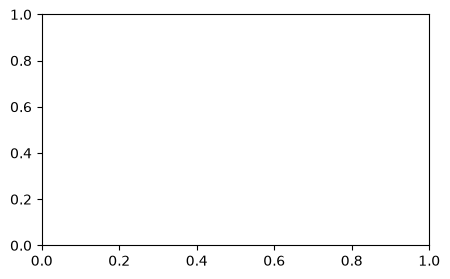

In [ ]:
# Let's take a look to the training and validation loss curves
from previous_chapters import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

**Exercise 7.3: Fine-tuning on the original Alpaca dataset**

The Alpaca dataset, by researchers at Stanford, is one of the earliest and most popular openly shared instruction datasets, consisting of 52,002 entries. As an alternative to the instruction-data.json file we use here, consider fine-tuning an LLM on this dataset. The dataset is available at https://mng.bz/NBnE.

### Extracting and saving responses
Having fine-tuned the LLM on the training portion of the instruction dataset, we are now ready to evaluate its performance on the held-out test set. First, we extract the model-generated responses for each input in the test dataset and collect them for manual analysis, and then we evaluate the LLM to quantify the quality of the responses.

In [40]:
torch.manual_seed(123)

for entry in test_data[:3]:
  input_text = format_input(entry)
  token_ids = generate(
      model=model,
      idx=text_to_token_ids(input_text, tokenizer).to(device),
      max_new_tokens=256,
      context_size=BASE_CONFIG['context_length'],
      eos_id=50256,
  )
  generated_text = token_ids_to_text(token_ids, tokenizer)

  response_text = (
      generated_text[len(input_text):]
      .replace("### Response:", "")
      .strip()
      )
  print(input_text)
  print(f"\nCorrect response:\n>> {entry['output']}")
  print(f"\nModel response:\n>> {response_text.strip()}")
  print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prej

In [41]:
# We now use the generate function in the same way as before,
# but we append the model-generated responses to the test_set
# dictionary for later retrieval and evaluation
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
  input_text = format_input(entry)
  token_ids = generate(
      model=model,
      idx=text_to_token_ids(input_text, tokenizer).to(device),
      max_new_tokens=256,
      context_size=BASE_CONFIG['context_length'],
      eos_id=50256,
  )
  generated_text = token_ids_to_text(token_ids, tokenizer)
  response_text = (
      generated_text[len(input_text):]
      .replace("### Response:", "")
      .strip()
      )
  test_data[i]['model_response'] = response_text

with open("instruction-data-with-response.json", "w") as file:
  json.dump(test_data, file, indent=2)

100%|██████████| 110/110 [16:06<00:00,  8.79s/it]


In [42]:
# Let's see if the model responses have been correctly added to the
# test_data dictionary
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


In [43]:
# Finally, we save the fine-tuned model as a file so we can reuse it
# in later sessions
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


### Evaluating the fine-tuned model

In [ ]:
# We will use another LLM to judge the response of our fine tuned gpt2 model and
# we will use ollama to run this judge model. This code checks if the ollama
# process is running in background
import psutil

def check_if_running(process_name):
  running = False
  for proc in psutil.process_iter(['name']):
    if process_name in proc.info['name']:
      running = True
      break
  return running

ollama_running = check_if_running("ollama")

if not ollama_running:
  raise RuntimeError(
      "Ollama not running. Launch ollama before proceeding."
  )

print("Ollama running:", check_if_running("ollama"))

In [46]:
import urllib.request

def query_model(
    prompt, 
    model="llama3", 
    url="http://localhost:11434/api/chat"
):
    data = {             #1
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {         #2
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }


    payload = json.dumps(data).encode("utf-8")    #3
    request = urllib.request.Request(                       #4
        url,                                                #4
        data=payload,                                       #4
        method="POST"                                       #4
    ) #4

    request.add_header("Content-Type", "application/json")   #4

    response_data = ""
    with urllib.request.urlopen(request) as response:   #5
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data

In [47]:
model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy munching on hay cubes or loose hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their diet. However, these should be given in moderation to avoid digestive issues.
4. Fruits and vegetables: Fresh fruits and veggies can be a tasty treat for llamas. Some favorites include apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas need access to mineral supplements, such as salt licks or loose minerals, to ensure they're getting the necessary nutrients.

In general, a llama's diet should consist of:

* 70-80% grasses and hay
* 10-20% grains and fruits/vegetables
* 5-10% minerals and treats

It's essenti

In [48]:
# Now we can ask the Llama 3 model to rate our fine-tuned GPT-2 model's
# response on the basis of the reference response. We apply this to the
# first three samples of the test set to see how this works
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> I'd rate the model response "The car is as fast as a bullet." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to something else (in this case, a bullet).
* The comparison is relevant and makes sense, as bullets are known for their high velocity.
* The phrase "as fast as" is used correctly to introduce the simile.

The only reason I wouldn't give it a perfect score is that some people might not immediately think of a bullet when they hear "fast", whereas lightning is often associated with speed. However, "a bullet" is still a common and effective comparison for conveying rapid movement.

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.

Score:
>> I'd score t

In [49]:
# The generate_model_scores function shown in the following listing uses a modified prompt 
# telling the model to "Respond with the integer number only."
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores

In [50]:
# Let's score the whole test dataset
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [08:26<00:00,  4.61s/it]

Number of scores: 110 of 110
Average score: 47.94



**Exercise 7.4: Parameter-Efficient Fine-Tuning with LoRA**

To instruction fine-tune an LLM more efficiently, modify the code in this chapter to use the low-rank adaptation method (LoRA). Compare the training run time and model performance before and after the modification.